# Week 12 - Scientific Data Analysis

## Learning objectives

- Getting familiar with the basic steps in a scientific data analysis pipeline.
- Consolidating and reviewing a large subset of the topics from throughout the course in one unified task.
- Combining and integrating independent concepts to solve real-world problems.
- Getting started with `pandas`.
- Getting familiar with summarizing and presenting analysis outputs.
- Reinforcing scientific reasoning and critical thinking.
- Learning how to use the user manual of libraries.

## Overview

In the previous tutorials, we have tackled a wide range of scientific programming concepts, from procedural and object-oriented programming to algorithms and complexity analysis.

It is now apt to put these skills to practical use to solve a real-world problem, namely a typical scientific data analysis pipeline, which is, on the one hand, extremely useful and interesting for scientists in its own right, and on the other, offers us the opportunity to use, if not all, a significant portion of the concepts we have learned throughout the course in an integrated manner. Finally, we will get familiar with the `pandas` library in the course of this tutorial. In this regard, a learning objective of this tutorial is to get you comfortable using libraries you may not be experts in by using their user manuals, which is a valuable skill for any programmer.

You can find the user manual of `pandas` [here](https://pandas.pydata.org/docs/user_guide/index.html).

## Problem description

In a laboratory experiment, the cooling of heated objects made from different materials is studied. For each material, the object is heated to a high initial temperature and then allowed to cool down in the same ambient conditions. A temperature sensor records the temperature at different times.

The experiment is repeated for several materials, e.g., aluminum, steel, etc. in order to compare their cooling behavior.

As is common in real experiments, the recorded data is not perfectly clean, i.e.,

- some measurements may be missing,
- some entries may be invalid or corrupted, and
- small fluctuations and noise are present.

Your task is to analyze this measurement data and extract meaningful information about the cooling behavior of the different materials.

### Dataset

The data is provided in a CSV file named `measurement_data.csv` along with this notebook with the following columns:

- `material`: name of the material used in the experiment.
- `time`: time in seconds since the start of the experiment. `0` indicates the initial conditions.
- `temperature`: measured temperature in degrees Celsius at the corresponding time.

**Assumptions**

- The rows are **not** in any particular order, neither by time nor material.
- The file may contain missing or non-numeric values which should be handled appropriately.

## Loading and inspecting the data

The first step is naturally to import the data into Python in an appropriate **data structure**. As mentioned, we are going to use `pandas` for this purpose. In particular, we would like to read in the data into `pandas DataFrame`.

In addition, it is often useful to inspect the data, at least superficially at this stage in order to ensure that the input data conforms to our expectations in general.

At this stage, we do not intend to modify the data yet. The goal is to understand what the raw input looks like before processing it further.

In [3]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
"""
- Import the measurement data from measurement_data.csv into a pandas DataFrame.
- Display the first few rows of the dataset.
- Print the column names.
- Print the data types of each column.
""";

# Code here
# Read the data
raw_data = pd.read_csv("measurement_data.csv")
df_raw = pd.DataFrame(data=raw_data)
# Show the head
print("My few columns dataset:")
print(df.head())
# Show the column names
print("Column names:")
df.columns.tolist()
data_list = df_raw.columns.tolist()
# Print data type each columns
#for i in range(0, len(data_list)-1):
#    print(df.iloc[i])

print(df.dtypes)

My few columns dataset:


NameError: name 'df' is not defined

## Data cleaning and validation

Real-world measurement data is rarely perfect. Therefore, before any meaningful analysis can be performed, the data has to be cleaned and validated.

We are going to approach this task in a few steps.

**Cleaning**

- The **data must be converted into appropriate formats**. In our case, this means that columns containing numbers must be converted to numerical values, and **invalid or non-numeric entries** must be indicated, e.g., by `NaN`. **Hint**: The function `pd.to_numeric` can be used to convert a column to numeric values. The argument `errors="coerce"` replaces invalid entries with `NaN`.
- After conversion, some rows may contain **missing values**. Remove all rows that contain at least one missing value, and store the cleaned data in a **new DataFrame**. **Hint**: The method `DataFrame.dropna` removes rows with missing values.
- Since, as discussed, the raw data is assumed to be unordered, the data must be sorted next. Sort the data by `material` and then by `time` in ascending order. **Hint**: The method `DataFrame.sort_values` can sort by one or multiple columns.
- Another important step in cleaning the data is to ensure that the data is logically, physically, etc. correct. In our case, temperature of the object should generally decrease to the ambient temperature over time; therefore, although small fluctuations due to noise are expected, large increases are likely incorrect measurements. Assume that the measurement equipment has an accuracy of $\pm 1^{\circ} C$. For each material, identify time steps where the temperature increases above the threshold and decide on a simple rule to remove or flag these inconsistent measurements.

**Validation**

- Print the number of remaining rows.
- Check that all values in `time` and `temperature` are numeric.
- Verify that the `material` column still contains valid material names.
- Determine how many rows were removed for each material. **Hint**: You may find the functions `groupby` combined with `size` useful for this task.

    material  time  temperature
8   Aluminum     0        150.0
32  Aluminum    10        135.0
60  Aluminum    20        121.0
24  Aluminum    30        108.0
44  Aluminum    40         96.0
..       ...   ...          ...
17     Steel   160         62.0
65     Steel   170         61.0
57     Steel   180         60.0
73     Steel   190         59.0
37     Steel   200         58.0

[76 rows x 3 columns]


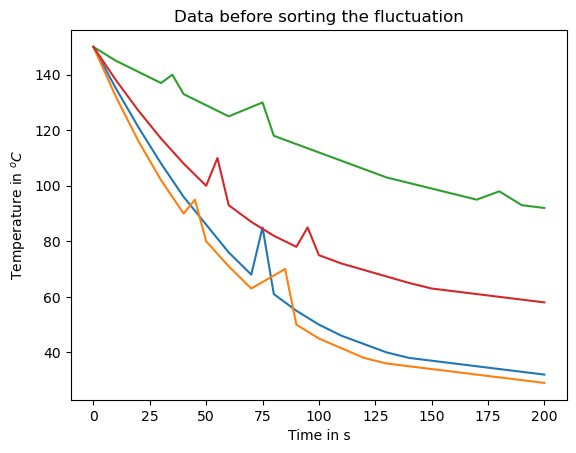

In [5]:
"""
- Clean the raw data and store it in a new DataFrame.
- Validate the cleaned data.
""";

# Code here
#print(df.iloc[:,1])
#pd.to_numeric(df.iloc[:,1], errors="coerce")
df = df_raw.copy()

# Clean the data
df["time"] = pd.to_numeric(df["time"], errors="coerce")
df["temperature"] = pd.to_numeric(df["temperature"], errors="coerce")

# Remove the nan
df_clean = df.dropna()

# Clean the data
df_clean = df_clean.sort_values(by=["material", "time"])

# Try to plot the data which have jump in it
for materials in df_clean["material"].unique():
    plt.plot(df_clean[df_clean["material"] == materials]["time"], df_clean[df_clean["material"] == materials]["temperature"])
plt.title("Data before sorting the fluctuation")
plt.xlabel("Time in s")
plt.ylabel("Temperature in $^o C$")

# Try to calculate the temperature difference
temp_diff = df_clean.groupby("material")["temperature"].diff()
threshold = 0

invalid_mask = temp_diff > threshold

df_clean = df_clean.drop(df_clean.index[invalid_mask])
print(df_clean)

## Exploratory data analysis

Before fitting any models or drawing conclusions, it is important to explore the cleaned data and build intuition about its structure and behavior. To this end, simple statistical measures are often employed.

Here, we will explore the following features:

- Identify the number of materials tested in the experiment and print a list of material names. **Hint**: The methods `unique` and `nunique` applied to the `material` column may be helpful.
- The minimum, maximum, and mean temperature across all measurements. **Hint**: DataFrame methods such as `min`, `max`, and `mean` can be applied directly to columns.
- An important maneuver is to be able to analyze a certain portion of the data. In this case, naturally, questions can be posed on each material, e.g., it would be interesting to compute the same values, namely the minimum, maximum and mean temperature values but this time for each material separately. As you will see, this is a very typical and useful processing skill. **Hint**: The method `DataFrame.groupby` can be used to group rows by the material column. Aggregation functions such as `min`, `max` and `mean` can then be applied to each group.
- Similarly, it could be interesting to see if data for all materials is available across the same time span. For each material, determine the minimum and maximum measurement time and
identify any differences between materials. **Hint**: The method `DataFrame.groupby` comes in handy here as well.

**Interpretation**

At this stage, you should be able to answer some questions about the data **qualitatively** based on simple statistics, without referring to models, e.g.,

- Which material appears to cool down fastest based on the exploratory statistics?
- Are there any noticeable differences in the amount or range of data available for each material?

In [7]:
"""
- Compute the exploratory features above.
- Answer the qualitative questions.
""";

# Code here
print("The tested material in the experiment:")
# nunique stands for the number of unique
print(df_clean["material"].nunique())
print(f'my list of material: {df_clean["material"].unique()}")

# Statistic on the global value
print(f"Maximum global temperature value: {df_clean["temperature"].max()}")
print(f"Minimum global temperature value: {df_clean["temperature"].min()}")
print(f"Average global temperature value: {df_clean["temperature"].mean()}")

# For each of temperature
print(df_clean.groupby("material")["temperature"].agg(("max", "min", "mean")))

# For each of time
print(df_clean.groupby("material")["time"].agg(("max", "min")))

## TEST FUNCTION ##
print("My Aluminum data:")
# 1. Create a boolean mask where 'material' is 'Aluminum'
mask = df_clean["material"] == "Aluminum"

# 2. Apply the mask to the DataFrame to extract only those rows
df_aluminum = df_clean[mask]
print(df_aluminum["temperature"].head())

print("My Steel temperature data:")
print(df_clean[df_clean["material"] == "Steel"]["temperature"].head())

SyntaxError: f-string: unmatched '[' (53707151.py, line 13)

## Visualization of raw data

Visualization is a central tool in scientific data analysis. Well-designed plots help to identify trends, compare experimental conditions and detect potential issues in the data. Luckily, we have gathered quite a bit of experience with visualization tools such as `matplotlib` in the previous tutorials.

Your task is to create a plot of temperature in degrees Celsius on the vertical axis versus time in seconds on the horizontal axis for each material. The plot must have, in addition, a title, a legend, a grid and appropriate labels for each axis, indicating the quantity and its unit.

Based on the plot

- Compare the cooling behavior of the different materials.
- Identify any obvious outliers or irregularities.

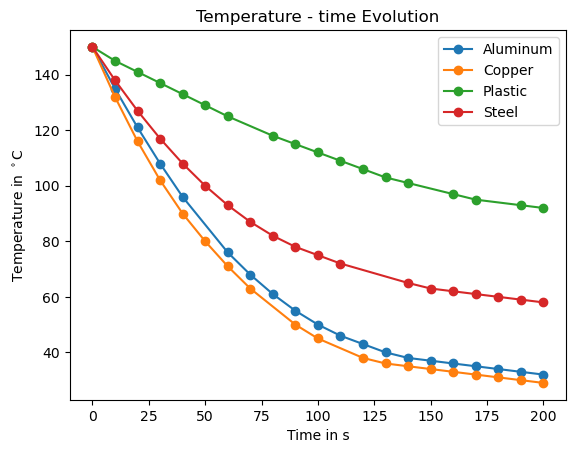

In [158]:
"""
- Plot temperature versus time for each material.
- Analyze the results.
""";

# Code here
for materials in df_clean["material"].unique():
    plt.plot(df_clean[df_clean["material"] == materials]["time"], df_clean[df_clean["material"] == materials]["temperature"], label=materials, marker='o')

plt.title("Temperature - time Evolution")
plt.legend()
plt.xlabel("Time in s")
plt.ylabel("Temperature in $^\circ$C")
plt.show()

## Quantitative analysis

We have, so far, prepared the raw data and explored and visualized the cleaned measurement data qualitatively. In this section, we will perform a simple quantitative analysis by fitting a basic model to the cooling data.

The goal is not to obtain a perfect physical description, but to extract a simple numerical characterization of the cooling behavior for each material.

### Model assumptions

We are going to limit ourselves to polynomial models in the following. More specifically, we are going to model the temperature evolution using a function

\begin{equation}
T(t) = \sum_{i=0}^{n} a_{i}t^{i},
\end{equation}

where $T$ is temperature, $t$ is time, $n$ is the maximum polynomial degree and $a_{i}$ are constants.

The fitting procedure then is essentially finding the *best*, in some well-defined sense, coefficients $a_{i}$ for the given data. Given that the emphasis here is not the mathematical procedure of finding the best fit, we are going to use the function `polyfit(x, y, degree = n)` from the `numpy` library which takes inputs `x` and `y` and uses least squares fitting to return the coefficients of a polynomial function with degree `n`.

To make matters even simpler, let us focus on polynomials with degree $1$ and $2$ only.

Note that it is meaningful to build these models for each material separately. We would like to create and store a linear and quadratic model for each material. **Hint**: The same mechanism for grouping the data by `material` is also applicable here.

Also note that storing the models in this case essentially boils down to storing the coefficients $a_{i}$. Alternatively, and arguably more flexibly, you can create a `numpy` polynomial object as `np.poly1d(coeffs)` where `coeffs` are the list of coefficients.

### Interpretation

Try to answer the following questions regarding the models:

- What does the sign and magnitude of the slope represent in this context?
- Which material has the largest cooling rate according to the linear models? Write an automated way to find this material.
- Which of the two models represent a better fit for each material? How can this be quantified?
**Hint**: One way to quantify how well a given function $\hat{f}$ fits an observed data $(x_{i}, y_{i})$ is to compute the coefficient of determination $R^{2}$ as

\begin{equation}
R^{2} = 1 - \frac{\text{SSR}}{\text{SST}},
\end{equation}

where $\text{SST} = \sum_{i = 1}^{n} (y_{i} - \bar{y})^{2}$, $\bar{y}$ is the sample mean and $\text{SSR} = \sum_{i = 1}^{n} (y_{i} - \hat{f}(x_{i}))^{2}$.

$R^{2}$ values closer to $1$ indicate a better fit, see [this article](https://en.wikipedia.org/wiki/Coefficient_of_determination) for more details.

Write a function that computes the $R^{2}$ value for a given fitted function $\hat{f}$ and an observed data $(x_{i}, y_{i})$, and compute the $R^{2}$ value for each model.

- Does it make sense to use higher order models? Why? **Hint**: Think about the physical process that the data corresponds to.

In [ ]:
"""
- Create and store the models as described above for each material.
  Although completely optional, you can use a pandas DataFrame to store this information! (Why would it be beneficial?)
- Answer the questions above.
""";

# Code here

## Visualization of the results

Visual comparison of data and model predictions is an essential step in scientific analysis, which allows for a ready, human-accessible assessment of how well a model captures the main trends in the data and to identify systematic deviations.

In this section, we are going to recreate the plot of temperature versus time using the cleaned data, but this time add the fitted models. The presentation of the data in a clear and appealing manner is in itself a topic worth spending some time on, and here, I would like you to pause and think about how you could best visualize the data from this seemingly simple analysis on a single plot such that it is legible and clear to the viewer while at the same time includes all the relevant information before seeing the suggestions below.

One way to present the data would be to visualize the cleaned data as a scattered plot, visualize each model with a different line, e.g., a continuous line for the linear model and a dashed line for the quadratic model and give each material a different color. In addition, the plot must contain a title, appropriate axis labels, indicating the quantity and its unit, a legend and a grid. Optionally, you could print the $R^{2}$ value corresponding to each model either on the plot itself or in the legend.

Also note that while plotting the fitted curves, you can use a denser sample space to get a smoother curve. **Hint**: you can use `np.linspace` to create the sample space.

### Interpretation

Answer the following questions based on the visualization:

- For which material do the models describe the data well? Can you visually see a correspondence to the $R^{2}$ values computed earlier?
- What additional plots can you think of to visualize the results?

In [ ]:
"""
- Create the plot as described above to visualize the cleaned data along with the fitted models
""";

# Code here

## Summary and report

Finally, a data analysis pipeline would not be complete without an appropriate report, summarizing the problem, data and the most important aspects of the results. Creating a good report is arguably as much art as science and designing a good report requires lots of practice and experience.

Even for our relatively simple task, one can see a variety of possibilities regarding what should be presented and how. Again, I would like you to pause here and think about this problem yourselves, take some notes and compare them with the guideline below.

Create a report that includes

- The list of tested materials.
- The start/end time and temperature and the fitted cooling rate from the linear model for each material as well as how well the linear model fits the data ($R^{2}$).
- The material with the fastest cooling rate.

You are free to format the report as you like and add any additional information you find useful/interesting.

In [ ]:
"""
- Create the report.
""";

# Code here

Copyright 2024 &copy; Manuel Saberi, High Performance Computing, Ruhr University Bochum. All rights reserved. No part of this notebook may be reproduced, distributed, or transmitted in any form or by any means, including photocopying, recording, or other electronic or mechanical methods, without the prior written permission of the publisher.